# Precision Medicine Toolbox - Worker Functionality Testing

This notebook provides comprehensive testing for all worker functionalities used in the API:
- **convert_to_nrrd**: Converting DICOM data to NRRD format
- **preprocess**: Applying various preprocessing techniques to NRRD data
- **nrrd_to_dicom**: Converting preprocessed NRRD back to DICOM format

## Purpose
- Test existing functionalities systematically
- Validate output quality and file integrity
- Prepare framework for developing and testing new features
- Provide clear examples for each function

## 1. Import Required Libraries and Modules

In [ ]:
# Standard library imports
import os
import sys
import shutil
import glob
import traceback
from pathlib import Path
import time
from datetime import datetime

# Data handling and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Precision Medicine Toolbox modules
from pmtool.ToolBox import ToolBox
from pmtool.AnalysisBox import AnalysisBox
from pmtool.GenerateResultBox import GenerateResultBox

# For testing the worker functions directly
import worker
from schemas import ConvertToNRRDJob, PreprocessJob, NrrdToDicomJob

print("All libraries imported successfully!")
print(f"Current working directory: {os.getcwd()}")
print(f"Python version: {sys.version}")
print(f"Test started at: {datetime.now()}")

## 2. Setup Test Data Paths and Parameters

In [ ]:
# Base configuration for testing
class TestConfig:
    """Configuration class for organizing test parameters"""
    
    def __init__(self, base_path=None):
        # Use the existing data directory or create new test directory
        if base_path is None:
            self.base_path = Path(os.getcwd()) / "test_data"
        else:
            self.base_path = Path(base_path)
        
        # Create test directory structure
        self.dicom_data_path = self.base_path / "dicom_input"
        self.nrrd_output_path = self.base_path / "converted_nrrds" 
        self.preprocessed_path = self.base_path / "preprocessed"
        self.final_dicom_path = self.base_path / "converted_dicoms"
        
        # Ensure directories exist
        for path in [self.dicom_data_path, self.nrrd_output_path, 
                    self.preprocessed_path, self.final_dicom_path]:
            path.mkdir(parents=True, exist_ok=True)
        
        print(f"Test configuration initialized:")
        print(f"  Base path: {self.base_path}")
        print(f"  DICOM input: {self.dicom_data_path}")
        print(f"  NRRD output: {self.nrrd_output_path}")
        print(f"  Preprocessed: {self.preprocessed_path}")
        print(f"  Final DICOM: {self.final_dicom_path}")

# Initialize test configuration
# Option 1: Use existing data directory
test_config = TestConfig(base_path="data2")

# Option 2: Use new test directory (uncomment if needed)
# test_config = TestConfig()



In [ ]:
# Utility functions for testing
def check_directory_contents(directory_path, description="Directory"):
    """Check and display contents of a directory"""
    path = Path(directory_path)
    if not path.exists():
        print(f"❌ {description} does not exist: {path}")
        return False
    
    files = list(path.rglob("*"))
    file_count = len([f for f in files if f.is_file()])
    dir_count = len([f for f in files if f.is_dir()])
    
    print(f"✅ {description}: {path}")
    print(f"   Files: {file_count}, Directories: {dir_count}")
    
    # Show some example files
    example_files = [f for f in files if f.is_file()][:5]
    if example_files:
        print("   Example files:")
        for file in example_files:
            size = file.stat().st_size if file.exists() else 0
            print(f"     - {file.name} ({size:,} bytes)")
    
    return True

def measure_execution_time(func, *args, **kwargs):
    """Measure execution time of a function"""
    start_time = time.time()
    try:
        result = func(*args, **kwargs)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"⏱️ Execution time: {execution_time:.2f} seconds")
        return result, execution_time, None
    except Exception as e:
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"❌ Function failed after {execution_time:.2f} seconds: {str(e)}")
        return None, execution_time, str(e)

def create_test_report(test_name, success, execution_time, error=None, details=None):
    """Create a structured test report"""
    report = {
        "test_name": test_name,
        "timestamp": datetime.now().isoformat(),
        "success": success,
        "execution_time": execution_time,
        "error": error,
        "details": details
    }
    return report

print("Utility functions defined successfully!")

## 3. Test Convert DICOM to NRRD Functionality

This section tests the `convert_to_nrrd` function from the worker module. The function converts DICOM medical imaging data to NRRD (Nearly Raw Raster Data) format, which is commonly used for medical image processing.

In [ ]:
def test_convert_to_nrrd(data_path, export_path, test_name="DICOM to NRRD"):
    """
    Test the convert_to_nrrd functionality
    
    Parameters:
    - data_path: Path to DICOM data
    - export_path: Path where NRRD files will be saved
    - test_name: Name for the test report
    """
    print(f"\n🔄 Testing {test_name}")
    print(f"Input: {data_path}")
    print(f"Output: {export_path}")
    
    # Check if input data exists
    if not check_directory_contents(data_path, "DICOM input directory"):
        return create_test_report(test_name, False, 0, "Input directory not found")
    
    # Prepare parameters (matching worker.py implementation)
    parameters = {
        'data_path': str(data_path),
        'data_type': 'dcm',
        'multi_rts_per_pat': False,
        'twod_image': True,
        'image_only': True
    }
    
    print(f"Parameters: {parameters}")
    
    def run_conversion():
        # Initialize ToolBox with parameters
        toolbox = ToolBox(**parameters)
        
        # Perform conversion
        toolbox.convert_to_nrrd(str(export_path))
        return str(export_path)
    
    # Execute with timing
    result, exec_time, error = measure_execution_time(run_conversion)
    
    if error:
        return create_test_report(test_name, False, exec_time, error)
    
    # Validate output
    output_valid = check_directory_contents(export_path, "NRRD output directory")
    
    # Look for converted_nrrds subdirectory (as per worker.py pattern)
    converted_nrrds_path = Path(export_path) / "converted_nrrds"
    if converted_nrrds_path.exists():
        check_directory_contents(converted_nrrds_path, "Converted NRRDs subdirectory")
    
    success = output_valid and result is not None
    details = {
        "parameters": parameters,
        "output_path": str(export_path),
        "files_created": output_valid
    }
    
    status = "✅ SUCCESS" if success else "❌ FAILED"
    print(f"{status}: {test_name}")
    
    return create_test_report(test_name, success, exec_time, error, details)

# Test with existing data
print("=== DICOM to NRRD Conversion Tests ===")

In [ ]:
# Run conversion test with available data
conversion_reports = []

# Test 1: Using data2/dcms2 if it exists
data2_dcms_path = Path("data2/dcms2")
if data2_dcms_path.exists():
    report1 = test_convert_to_nrrd(
        data_path=data2_dcms_path,
        export_path=test_config.base_path,
        test_name="DICOM to NRRD (data2/dcms2)"
    )
    conversion_reports.append(report1)
else:
    print("❌ data2/dcms2 not found, skipping this test")

# Test 3: Check for individual DICOM directories
dicom_dirs = []
for pattern in ["data2/**/LUNG*"]:
    dicom_dirs.extend(list(Path(".").glob(pattern)))

if dicom_dirs and len(conversion_reports) == 0:
    # Use first available DICOM directory
    first_dicom = dicom_dirs[0]
    report3 = test_convert_to_nrrd(
        data_path=first_dicom.parent,  # Use parent directory
        export_path=test_config.nrrd_output_path,
        test_name=f"DICOM to NRRD ({first_dicom.parent})"
    )
    conversion_reports.append(report3)

# Summary of conversion tests
print("\n" + "="*50)
print("CONVERSION TEST SUMMARY")
print("="*50)
for report in conversion_reports:
    status = "✅" if report["success"] else "❌"
    print(f"{status} {report['test_name']}: {report['execution_time']:.2f}s")
    if not report["success"] and report["error"]:
        print(f"   Error: {report['error']}")

if not conversion_reports:
    print("⚠️ No DICOM data found for testing. Please ensure DICOM data is available in:")
    print("   - data2/dcms2/")
    print("   - data/dcms/")
    print("   - Or individual LUNG directories")

## 4. Test Preprocessing Functionality

This section tests the `preprocess` function from the worker module. The function applies various preprocessing techniques to NRRD data including:
- Percentile scaling
- CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Z-score normalization
- Histogram equalization

In [ ]:
def test_preprocess(data_path, save_path, config_name="Default", preprocessing_config=None):
    """
    Test the preprocess functionality with various configurations
    
    Parameters:
    - data_path: Path to NRRD data
    - save_path: Path where preprocessed files will be saved  
    - config_name: Name for this configuration
    - preprocessing_config: Dict with preprocessing parameters
    """
    print(f"\n🔄 Testing Preprocessing: {config_name}")
    print(f"Input: {data_path}")
    print(f"Output: {save_path}")
    
    # Default preprocessing config (matching worker.py)
    if preprocessing_config is None:
        preprocessing_config = {
            "verbosity": True,
            "visualize": False,
            "clahe_apply": False,
            "z_score": False,
            "percentile_scaling": True,
            "hist_equalize": False
        }
    
    print(f"Config: {preprocessing_config}")
    
    # Check if input data exists
    if not check_directory_contents(data_path, "NRRD input directory"):
        return create_test_report(f"Preprocess_{config_name}", False, 0, "Input directory not found")
    
    def run_preprocessing():
        # Ensure output directory exists
        os.makedirs(save_path, exist_ok=True)
        
        # Initialize ToolBox for NRRD data
        toolbox = ToolBox(str(data_path), data_type="nrrd", twod_image=True, image_only=True)
        
        # Apply preprocessing
        toolbox.pre_process(save_path=str(save_path), **preprocessing_config)
        
        return str(save_path)
    
    # Execute with timing
    result, exec_time, error = measure_execution_time(run_preprocessing)
    
    if error:
        return create_test_report(f"Preprocess_{config_name}", False, exec_time, error)
    
    # Validate output
    output_valid = check_directory_contents(save_path, "Preprocessed output directory")
    
    success = output_valid and result is not None
    details = {
        "config": preprocessing_config,
        "input_path": str(data_path),
        "output_path": str(save_path),
        "files_created": output_valid
    }
    
    status = "✅ SUCCESS" if success else "❌ FAILED"
    print(f"{status}: Preprocessing {config_name}")
    
    return create_test_report(f"Preprocess_{config_name}", success, exec_time, error, details)

# Define different preprocessing configurations to test
preprocessing_configs = {
    # "Worker_Default": {
    #     "verbosity": True,
    #     "visualize": False,
    #     "clahe_apply": False,
    #     "z_score": False,
    #     "percentile_scaling": True,
    #     "hist_equalize": False
    # },
    # "CLAHE_Enhanced": {
    #     "verbosity": True,
    #     "visualize": False,
    #     "clahe_apply": True,
    #     "clahe_clip_limit": 2.0,
    #     "clahe_tile_grid_size": (8, 8),
    #     "z_score": False,
    #     "percentile_scaling": True,
    #     "hist_equalize": False
    # },
    # "Z_Score_Normalized": {
    #     "verbosity": True,
    #     "visualize": False,
    #     "clahe_apply": False,
    #     "z_score": True,
    #     "percentile_scaling": False,
    #     "hist_equalize": False
    # },
    "Full_Processing": {
        "verbosity": True,
        "visualize": False,
        "clahe_apply": True,
        "clahe_clip_limit": 3.0,
        "clahe_tile_grid_size": (4, 4),
        "z_score": True,
        "percentile_scaling": True,
        "hist_equalize": True
    }
}

print("Preprocessing configurations defined:")
for name, config in preprocessing_configs.items():
    techniques = [k for k, v in config.items() if v is True and k not in ['verbosity', 'visualize']]
    print(f"  - {name}: {', '.join(techniques) if techniques else 'percentile_scaling only'}")

In [ ]:
# Run preprocessing tests
print("\n=== PREPROCESSING TESTS ===")
preprocessing_reports = []

# Find NRRD data from previous conversion or existing data
nrrd_paths_to_test = []

# Check for converted NRRD data from previous test
converted_nrrd_path = test_config.base_path / "converted_nrrds"
if converted_nrrd_path.exists() and list(converted_nrrd_path.rglob("*.nrrd")):
    nrrd_paths_to_test.append(("converted_nrrds", converted_nrrd_path))

# Check for existing preprocessed data (to test on)
existing_nrrd_paths = [
    ("data2/converted_nrrds", Path("data2/converted_nrrds"))
]

for name, path in existing_nrrd_paths:
    if path.exists() and list(path.rglob("*.nrrd")):
        nrrd_paths_to_test.append((name, path))

if not nrrd_paths_to_test:
    print("⚠️ No NRRD data found for preprocessing tests")
    print("   Please run the DICOM to NRRD conversion first")
else:
    # Test each configuration on the first available NRRD dataset
    nrrd_name, nrrd_path = nrrd_paths_to_test[0]
    print(f"Using NRRD data from: {nrrd_path}")
    
    for config_name, config in preprocessing_configs.items():
        # Create unique output directory for each configuration
        output_path = test_config.preprocessed_path / config_name.lower()
        
        report = test_preprocess(
            data_path=nrrd_path,
            save_path=output_path,
            config_name=config_name,
            preprocessing_config=config
        )
        preprocessing_reports.append(report)
        
        # Small delay between tests
        time.sleep(1)

# Summary of preprocessing tests
print("\n" + "="*50)
print("PREPROCESSING TEST SUMMARY")
print("="*50)
for report in preprocessing_reports:
    status = "✅" if report["success"] else "❌"
    print(f"{status} {report['test_name']}: {report['execution_time']:.2f}s")
    if not report["success"] and report["error"]:
        print(f"   Error: {report['error']}")

# Show preprocessing output structure
if preprocessing_reports and any(r["success"] for r in preprocessing_reports):
    print("\n📁 Preprocessing output structure:")
    check_directory_contents(test_config.preprocessed_path, "All preprocessing outputs")

## 5. Test NRRD to DICOM Conversion Functionality

This section tests the `nrrd_to_dicom` function from the worker module. The function converts preprocessed NRRD data back to DICOM format, maintaining medical metadata and structure.

In [ ]:
def test_nrrd_to_dicom(nrrd_path, dcm_reference_path, output_dicom_dir, test_name="NRRD to DICOM"):
    """
    Test the nrrd_to_dicom functionality
    
    Parameters:
    - nrrd_path: Path to preprocessed NRRD data
    - dcm_reference_path: Path to original DICOM data (for metadata reference)
    - output_dicom_dir: Path where new DICOM files will be saved
    - test_name: Name for the test report
    """
    print(f"\n🔄 Testing {test_name}")
    print(f"NRRD Input: {nrrd_path}")
    print(f"DICOM Reference: {dcm_reference_path}")
    print(f"Output: {output_dicom_dir}")
    
    # Check inputs
    if not check_directory_contents(nrrd_path, "NRRD input directory"):
        return create_test_report(test_name, False, 0, "NRRD input directory not found")
    
    if not check_directory_contents(dcm_reference_path, "DICOM reference directory"):
        return create_test_report(test_name, False, 0, "DICOM reference directory not found")
    
    def run_conversion():
        # Ensure output directory exists
        os.makedirs(output_dicom_dir, exist_ok=True)
        
        # Initialize ToolBox for NRRD data
        toolbox = ToolBox(str(nrrd_path), data_type="nrrd", twod_image=True, image_only=True)
        
        # Convert NRRD to DICOM
        toolbox.convert_nrrd_to_dicom(
            nrrd_path=str(nrrd_path),
            dcm_path=str(dcm_reference_path),
            output_dicom_dir=str(output_dicom_dir)
        )
        
        return str(output_dicom_dir)
    
    # Execute with timing
    result, exec_time, error = measure_execution_time(run_conversion)
    
    if error:
        return create_test_report(test_name, False, exec_time, error)
    
    # Validate output
    output_valid = check_directory_contents(output_dicom_dir, "DICOM output directory")
    
    success = output_valid and result is not None
    details = {
        "nrrd_input": str(nrrd_path),
        "dcm_reference": str(dcm_reference_path),
        "output_path": str(output_dicom_dir),
        "files_created": output_valid
    }
    
    status = "✅ SUCCESS" if success else "❌ FAILED"
    print(f"{status}: {test_name}")
    
    return create_test_report(test_name, success, exec_time, error, details)

print("NRRD to DICOM test function defined!")

In [ ]:
# Run NRRD to DICOM conversion tests
print("\n=== NRRD TO DICOM CONVERSION TESTS ===")
nrrd_to_dicom_reports = []

# Find preprocessed NRRD data and corresponding DICOM references
test_pairs = []

# Check for preprocessed data from our tests
for config_name in preprocessing_configs.keys():
    preprocessed_path = test_config.preprocessed_path / config_name.lower()
    if preprocessed_path.exists() and list(preprocessed_path.rglob("*.nrrd")):
        # Find corresponding original DICOM data
        possible_dcm_paths = [
            Path("data2/dcms2"),
            Path("data/dcms"),
            Path("data2"),
            Path("data")
        ]
        
        for dcm_path in possible_dcm_paths:
            if dcm_path.exists():
                output_path = test_config.final_dicom_path / config_name.lower()
                test_pairs.append((
                    f"NRRD_to_DICOM_{config_name}",
                    preprocessed_path,
                    dcm_path,
                    output_path
                ))
                break

# Also check for existing preprocessed data
existing_preprocessed = [
    ("data2/preprocessed", Path("data2/preprocessed"), Path("data2/dcms2")),
    ("data/preprocessed", Path("data/preprocessed"), Path("data/dcms"))
]

for name, nrrd_path, dcm_path in existing_preprocessed:
    if nrrd_path.exists() and dcm_path.exists():
        if list(nrrd_path.rglob("*.nrrd")):
            output_path = test_config.final_dicom_path / "existing_data"
            test_pairs.append((
                f"NRRD_to_DICOM_{name.replace('/', '_')}",
                nrrd_path,
                dcm_path,
                output_path
            ))

if not test_pairs:
    print("⚠️ No preprocessed NRRD data found for NRRD to DICOM testing")
    print("   Please run the preprocessing tests first")
else:
    print(f"Found {len(test_pairs)} test pairs for NRRD to DICOM conversion")
    
    # Run tests (limit to first 2 to avoid excessive processing)
    for i, (test_name, nrrd_path, dcm_path, output_path) in enumerate(test_pairs[:2]):
        print(f"\n--- Test {i+1}/{min(len(test_pairs), 2)} ---")
        
        report = test_nrrd_to_dicom(
            nrrd_path=nrrd_path,
            dcm_reference_path=dcm_path,
            output_dicom_dir=output_path,
            test_name=test_name
        )
        nrrd_to_dicom_reports.append(report)
        
        # Small delay between tests
        time.sleep(1)

# Summary of NRRD to DICOM tests
print("\n" + "="*50)
print("NRRD TO DICOM TEST SUMMARY")
print("="*50)
for report in nrrd_to_dicom_reports:
    status = "✅" if report["success"] else "❌"
    print(f"{status} {report['test_name']}: {report['execution_time']:.2f}s")
    if not report["success"] and report["error"]:
        print(f"   Error: {report['error']}")

# Show final output structure
if nrrd_to_dicom_reports and any(r["success"] for r in nrrd_to_dicom_reports):
    print("\n📁 Final DICOM output structure:")
    check_directory_contents(test_config.final_dicom_path, "All DICOM outputs")

## 6. Validate Output Files and Structure

This section provides comprehensive validation of all outputs from the testing pipeline, including file integrity checks, data consistency verification, and structure analysis.

In [ ]:
def validate_file_integrity(directory_path, expected_extensions):
    """
    Validate file integrity and format in a directory
    
    Parameters:
    - directory_path: Path to check
    - expected_extensions: List of expected file extensions
    """
    print(f"\n🔍 Validating file integrity in: {directory_path}")
    
    if not Path(directory_path).exists():
        print(f"❌ Directory does not exist: {directory_path}")
        return False
    
    all_files = list(Path(directory_path).rglob("*"))
    data_files = [f for f in all_files if f.is_file() and f.suffix in expected_extensions]
    
    print(f"📊 Found {len(data_files)} files with expected extensions {expected_extensions}")
    
    # Check file sizes
    file_sizes = []
    corrupted_files = []
    
    for file_path in data_files:
        try:
            size = file_path.stat().st_size
            file_sizes.append(size)
            
            if size == 0:
                corrupted_files.append(file_path)
                print(f"⚠️ Empty file: {file_path}")
            elif size < 1024:  # Less than 1KB might indicate corruption
                print(f"⚠️ Very small file ({size} bytes): {file_path}")
                
        except Exception as e:
            corrupted_files.append(file_path)
            print(f"❌ Error reading file {file_path}: {e}")
    
    # Statistics
    if file_sizes:
        avg_size = np.mean(file_sizes)
        median_size = np.median(file_sizes)
        min_size = min(file_sizes)
        max_size = max(file_sizes)
        
        print(f"📈 File size statistics:")
        print(f"   Average: {avg_size:,.0f} bytes")
        print(f"   Median: {median_size:,.0f} bytes")
        print(f"   Range: {min_size:,.0f} - {max_size:,.0f} bytes")
    
    integrity_score = (len(data_files) - len(corrupted_files)) / max(len(data_files), 1)
    print(f"✅ Integrity score: {integrity_score:.1%} ({len(data_files) - len(corrupted_files)}/{len(data_files)} files valid)")
    
    return integrity_score > 0.9  # 90% of files should be valid

def compare_directory_structures(original_path, converted_path, description):
    """
    Compare directory structures between original and converted data
    """
    print(f"\n🔄 Comparing structures: {description}")
    print(f"Original: {original_path}")
    print(f"Converted: {converted_path}")
    
    if not (Path(original_path).exists() and Path(converted_path).exists()):
        print("❌ One or both directories don't exist")
        return False
    
    # Get directory structures
    orig_dirs = {str(d.relative_to(original_path)) for d in Path(original_path).rglob("*") if d.is_dir()}
    conv_dirs = {str(d.relative_to(converted_path)) for d in Path(converted_path).rglob("*") if d.is_dir()}
    
    # Get file counts per directory
    orig_files = {}
    conv_files = {}
    
    for dir_path in orig_dirs:
        full_path = Path(original_path) / dir_path
        orig_files[dir_path] = len([f for f in full_path.iterdir() if f.is_file()])
    
    for dir_path in conv_dirs:
        full_path = Path(converted_path) / dir_path
        conv_files[dir_path] = len([f for f in full_path.iterdir() if f.is_file()])
    
    # Compare
    common_dirs = orig_dirs.intersection(conv_dirs)
    missing_dirs = orig_dirs - conv_dirs
    extra_dirs = conv_dirs - orig_dirs
    
    print(f"📁 Directory comparison:")
    print(f"   Common directories: {len(common_dirs)}")
    print(f"   Missing in converted: {len(missing_dirs)}")
    print(f"   Extra in converted: {len(extra_dirs)}")
    
    if missing_dirs:
        print(f"   Missing: {list(missing_dirs)[:3]}{'...' if len(missing_dirs) > 3 else ''}")
    
    if extra_dirs:
        print(f"   Extra: {list(extra_dirs)[:3]}{'...' if len(extra_dirs) > 3 else ''}")
    
    # Check file count consistency for common directories
    file_consistency = True
    for dir_name in common_dirs:
        orig_count = orig_files.get(dir_name, 0)
        conv_count = conv_files.get(dir_name, 0)
        
        if orig_count > 0 and conv_count == 0:
            print(f"⚠️ No files converted in directory: {dir_name}")
            file_consistency = False
        elif orig_count > 0 and conv_count > 0:
            ratio = conv_count / orig_count
            if ratio < 0.5:  # Less than 50% of files converted
                print(f"⚠️ Low conversion ratio in {dir_name}: {conv_count}/{orig_count} ({ratio:.1%})")
    
    structure_score = len(common_dirs) / max(len(orig_dirs), 1) if orig_dirs else 1.0
    print(f"✅ Structure similarity: {structure_score:.1%}")
    
    return structure_score > 0.7 and file_consistency

print("Validation functions defined!")

In [ ]:
# Run validation tests
print("\n=== OUTPUT VALIDATION TESTS ===")

validation_results = []

# 1. Validate NRRD outputs
print("\n1️⃣ NRRD Output Validation")
nrrd_paths = [
    test_config.base_path / "converted_nrrds",
    test_config.nrrd_output_path,
    Path("data2/converted_nrrds"),
]

for nrrd_path in nrrd_paths:
    if nrrd_path.exists():
        result = validate_file_integrity(nrrd_path, [".nrrd", ".nhdr"])
        validation_results.append(("NRRD_integrity", nrrd_path, result))
        break

# 2. Validate preprocessed outputs
print("\n2️⃣ Preprocessed Output Validation")
if test_config.preprocessed_path.exists():
    for config_dir in test_config.preprocessed_path.iterdir():
        if config_dir.is_dir():
            result = validate_file_integrity(config_dir, [".nrrd", ".nhdr"])
            validation_results.append(("Preprocessed_integrity", config_dir, result))

# 3. Validate final DICOM outputs
print("\n3️⃣ Final DICOM Output Validation")
if test_config.final_dicom_path.exists():
    for dicom_dir in test_config.final_dicom_path.iterdir():
        if dicom_dir.is_dir():
            result = validate_file_integrity(dicom_dir, [".dcm", ".dicom", ""])
            validation_results.append(("Final_DICOM_integrity", dicom_dir, result))

# 4. Structure comparison tests
print("\n4️⃣ Structure Comparison Tests")

# Compare original DICOM vs converted NRRD structure
original_dicom_paths = [Path("data2/dcms2")]
converted_nrrd_paths = [test_config.base_path / "converted_nrrds", Path("data2/converted_nrrds")]

for orig_path, conv_path in zip(original_dicom_paths, converted_nrrd_paths):
    if orig_path.exists() and conv_path.exists():
        result = compare_directory_structures(orig_path, conv_path, "DICOM vs NRRD")
        validation_results.append(("Structure_DICOM_NRRD", f"{orig_path} vs {conv_path}", result))
        break

# Compare preprocessed vs final DICOM structure
if test_config.preprocessed_path.exists() and test_config.final_dicom_path.exists():
    # Find matching directories
    prep_dirs = [d for d in test_config.preprocessed_path.iterdir() if d.is_dir()]
    final_dirs = [d for d in test_config.final_dicom_path.iterdir() if d.is_dir()]
    
    for prep_dir in prep_dirs:
        matching_final = [f for f in final_dirs if prep_dir.name in f.name]
        if matching_final:
            result = compare_directory_structures(prep_dir, matching_final[0], f"Preprocessed vs Final DICOM ({prep_dir.name})")
            validation_results.append(("Structure_Prep_Final", f"{prep_dir.name}", result))

# 5. Data consistency checks
print("\n5️⃣ Data Consistency Checks")

def check_pipeline_consistency():
    """Check if data flows consistently through the pipeline"""
    consistency_score = 0
    total_checks = 0
    
    # Check if NRRD conversion produced output
    nrrd_exists = any(path.exists() and list(path.rglob("*.nrrd")) for path in nrrd_paths[:2])
    if nrrd_exists:
        consistency_score += 1
        print("✅ NRRD conversion pipeline stage complete")
    else:
        print("❌ NRRD conversion pipeline stage incomplete")
    total_checks += 1
    
    # Check if preprocessing produced output
    prep_exists = test_config.preprocessed_path.exists() and any(d.is_dir() for d in test_config.preprocessed_path.iterdir())
    if prep_exists:
        consistency_score += 1
        print("✅ Preprocessing pipeline stage complete")
    else:
        print("❌ Preprocessing pipeline stage incomplete")
    total_checks += 1
    
    # Check if final DICOM conversion produced output
    final_exists = test_config.final_dicom_path.exists() and any(d.is_dir() for d in test_config.final_dicom_path.iterdir())
    if final_exists:
        consistency_score += 1
        print("✅ Final DICOM conversion pipeline stage complete")
    else:
        print("❌ Final DICOM conversion pipeline stage incomplete")
    total_checks += 1
    
    pipeline_score = consistency_score / total_checks if total_checks > 0 else 0
    print(f"🔄 Pipeline consistency: {pipeline_score:.1%} ({consistency_score}/{total_checks} stages complete)")
    
    return pipeline_score > 0.66  # At least 2/3 stages should be complete

pipeline_consistent = check_pipeline_consistency()
validation_results.append(("Pipeline_consistency", "Full pipeline", pipeline_consistent))

# Summary of validation results
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)

passed = 0
total = 0

for test_type, path, result in validation_results:
    status = "✅ PASS" if result else "❌ FAIL"
    print(f"{status} {test_type}: {Path(str(path)).name if hasattr(path, 'name') else str(path)}")
    if result:
        passed += 1
    total += 1

overall_score = passed / total if total > 0 else 0
print(f"\n🎯 Overall validation score: {overall_score:.1%} ({passed}/{total} tests passed)")

if overall_score >= 0.8:
    print("🎉 Excellent! The worker functionalities are working correctly.")
elif overall_score >= 0.6:
    print("👍 Good! Most worker functionalities are working with minor issues.")
elif overall_score >= 0.4:
    print("⚠️ Moderate! Some worker functionalities need attention.")
else:
    print("🚨 Poor! Multiple worker functionalities need debugging.")

## 7. Performance and Error Testing

This section implements performance benchmarks and error handling tests to ensure robust functionality under various conditions and edge cases.

In [ ]:
# Performance and Error Testing Functions
import psutil
import gc
from contextlib import contextmanager

@contextmanager
def monitor_resources():
    """Context manager to monitor system resources during execution"""
    process = psutil.Process()
    
    # Initial measurements
    initial_memory = process.memory_info().rss / 1024 / 1024  # MB
    initial_cpu_percent = process.cpu_percent()
    start_time = time.time()
    
    print(f"🔋 Initial memory usage: {initial_memory:.1f} MB")
    
    try:
        yield
    finally:
        # Final measurements
        end_time = time.time()
        final_memory = process.memory_info().rss / 1024 / 1024  # MB
        avg_cpu_percent = process.cpu_percent()
        
        execution_time = end_time - start_time
        memory_delta = final_memory - initial_memory
        
        print(f"⏱️ Execution time: {execution_time:.2f} seconds")
        print(f"🧠 Memory usage: {final_memory:.1f} MB (Δ {memory_delta:+.1f} MB)")
        print(f"⚡ CPU usage: {avg_cpu_percent:.1f}%")

def test_error_conditions():
    """Test various error conditions and edge cases"""
    print("\n🧪 Testing Error Conditions and Edge Cases")
    
    error_tests = []
    
    # Test 1: Non-existent input directory
    print("\n1️⃣ Testing with non-existent input directory")
    try:
        toolbox = ToolBox("non_existent_path", data_type="dcm", twod_image=True, image_only=True)
        error_tests.append(("Non-existent input", False, "Should have failed but didn't"))
    except Exception as e:
        error_tests.append(("Non-existent input", True, str(e)))
        print(f"✅ Correctly failed: {type(e).__name__}")
    
    # Test 2: Invalid data type
    print("\n2️⃣ Testing with invalid data type")
    try:
        if Path("data2").exists():
            toolbox = ToolBox("data2", data_type="invalid_type", twod_image=True, image_only=True)
            error_tests.append(("Invalid data type", False, "Should have failed but didn't"))
        else:
            error_tests.append(("Invalid data type", True, "Skipped - no test data"))
    except Exception as e:
        error_tests.append(("Invalid data type", True, str(e)))
        print(f"✅ Correctly failed: {type(e).__name__}")
    
    # Test 3: Invalid preprocessing parameters
    print("\n3️⃣ Testing preprocessing with invalid parameters")
    try:
        # Find any existing NRRD data
        nrrd_paths = [Path("data2/converted_nrrds"), test_config.base_path / "converted_nrrds"]
        test_nrrd_path = None
        
        for path in nrrd_paths:
            if path.exists() and list(path.rglob("*.nrrd")):
                test_nrrd_path = path
                break
        
        if test_nrrd_path:
            toolbox = ToolBox(str(test_nrrd_path), data_type="nrrd", twod_image=True, image_only=True)
            # Test with invalid CLAHE parameters
            toolbox.pre_process(
                save_path=str(test_config.base_path / "error_test"),
                clahe_apply=True,
                clahe_clip_limit=-1,  # Invalid negative value
                clahe_tile_grid_size=(0, 0)  # Invalid zero size
            )
            error_tests.append(("Invalid preprocessing params", False, "Should have failed but didn't"))
        else:
            error_tests.append(("Invalid preprocessing params", True, "Skipped - no NRRD data"))
    except Exception as e:
        error_tests.append(("Invalid preprocessing params", True, str(e)))
        print(f"✅ Correctly handled invalid parameters: {type(e).__name__}")
    
    # Test 4: Memory stress test (if data is available)
    print("\n4️⃣ Testing memory handling with multiple operations")
    try:
        # Force garbage collection before test
        gc.collect()
        
        with monitor_resources():
            # Try to run multiple operations in sequence
            operations_completed = 0
            
            # Find small dataset for stress testing
            test_paths = [Path("data2"), Path("data")]
            small_dataset = None
            
            for path in test_paths:
                if path.exists():
                    subdirs = [d for d in path.iterdir() if d.is_dir()]
                    if subdirs:
                        small_dataset = subdirs[0]
                        break
            
            if small_dataset:
                for i in range(3):  # Try 3 iterations
                    try:
                        toolbox = ToolBox(str(small_dataset), data_type="dcm", twod_image=True, image_only=True)
                        # Just initialize, don't actually convert to save time
                        operations_completed += 1
                        del toolbox  # Explicit cleanup
                        gc.collect()
                    except Exception:
                        break
                
                error_tests.append(("Memory stress test", operations_completed >= 2, f"Completed {operations_completed}/3 operations"))
            else:
                error_tests.append(("Memory stress test", True, "Skipped - no test data"))
        
    except Exception as e:
        error_tests.append(("Memory stress test", False, str(e)))
    
    return error_tests

def benchmark_performance():
    """Benchmark performance of different operations"""
    print("\n📊 Performance Benchmarking")
    
    benchmarks = []
    
    # Find datasets of different sizes for benchmarking
    datasets = []
    
    # Check for various data directories
    for base_path in [Path("data"), Path("data2")]:
        if base_path.exists():
            for subdir in base_path.iterdir():
                if subdir.is_dir():
                    file_count = len(list(subdir.rglob("*")))
                    size_mb = sum(f.stat().st_size for f in subdir.rglob("*") if f.is_file()) / (1024 * 1024)
                    
                    if file_count > 10:  # Only consider directories with substantial content
                        datasets.append((subdir, file_count, size_mb))
    
    # Sort by size (smallest first for benchmarking)
    datasets.sort(key=lambda x: x[2])
    
    if datasets:
        # Test on smallest dataset
        test_dataset, file_count, size_mb = datasets[0]
        print(f"Benchmarking with dataset: {test_dataset}")
        print(f"Files: {file_count}, Size: {size_mb:.1f} MB")
        
        # Benchmark 1: ToolBox initialization
        print("\n🚀 Benchmarking ToolBox initialization")
        init_times = []
        
        for i in range(3):  # Run 3 times
            with monitor_resources():
                start = time.time()
                try:
                    toolbox = ToolBox(str(test_dataset), data_type="dcm", twod_image=True, image_only=True)
                    end = time.time()
                    init_times.append(end - start)
                    del toolbox
                    gc.collect()
                except Exception as e:
                    print(f"Initialization failed: {e}")
                    break
        
        if init_times:
            avg_init_time = np.mean(init_times)
            benchmarks.append(("ToolBox initialization", avg_init_time, f"{avg_init_time:.2f}s avg"))
            print(f"📈 Average initialization time: {avg_init_time:.2f}s")
        
        # Benchmark 2: Small conversion test (if we have very small dataset)
        if size_mb < 50:  # Only for very small datasets
            print(f"\n🔄 Benchmarking small conversion (dataset size: {size_mb:.1f} MB)")
            
            with monitor_resources():
                start = time.time()
                try:
                    toolbox = ToolBox(str(test_dataset), data_type="dcm", twod_image=True, image_only=True)
                    
                    # Create a temporary output directory
                    temp_output = test_config.base_path / "benchmark_temp"
                    temp_output.mkdir(exist_ok=True)
                    
                    toolbox.convert_to_nrrd(str(temp_output))
                    end = time.time()
                    
                    conversion_time = end - start
                    benchmarks.append(("Small conversion", conversion_time, f"{conversion_time:.2f}s for {size_mb:.1f}MB"))
                    print(f"📈 Conversion time: {conversion_time:.2f}s ({size_mb/conversion_time:.1f} MB/s)")
                    
                    # Cleanup
                    if temp_output.exists():
                        shutil.rmtree(temp_output, ignore_errors=True)
                    
                except Exception as e:
                    print(f"Conversion benchmark failed: {e}")
    
    else:
        print("⚠️ No suitable datasets found for benchmarking")
        benchmarks.append(("No datasets", 0, "Skipped - no data available"))
    
    return benchmarks

print("Performance and error testing functions defined!")

In [ ]:
# Execute Performance and Error Tests
print("\n=== PERFORMANCE AND ERROR TESTING ===")

# Run error condition tests
error_test_results = test_error_conditions()

# Run performance benchmarks
performance_results = benchmark_performance()

# Summary of all tests
print("\n" + "="*70)
print("COMPREHENSIVE TEST SUMMARY")
print("="*70)

# Collect all test results
all_tests = []

# Add main functionality test results
if 'conversion_reports' in locals():
    for report in conversion_reports:
        all_tests.append(("Conversion", report["test_name"], report["success"], report["execution_time"]))

if 'preprocessing_reports' in locals():
    for report in preprocessing_reports:
        all_tests.append(("Preprocessing", report["test_name"], report["success"], report["execution_time"]))

if 'nrrd_to_dicom_reports' in locals():
    for report in nrrd_to_dicom_reports:
        all_tests.append(("NRRD_to_DICOM", report["test_name"], report["success"], report["execution_time"]))

# Add validation results
if 'validation_results' in locals():
    for test_type, path, result in validation_results:
        all_tests.append(("Validation", test_type, result, 0))

# Add error test results
for test_name, passed, details in error_test_results:
    all_tests.append(("Error_Handling", test_name, passed, 0))

# Add performance results
for test_name, time_taken, details in performance_results:
    all_tests.append(("Performance", test_name, time_taken > 0, time_taken))

# Categorize results
categories = {}
for category, test_name, success, exec_time in all_tests:
    if category not in categories:
        categories[category] = {"passed": 0, "total": 0, "avg_time": 0, "times": []}
    
    categories[category]["total"] += 1
    if success:
        categories[category]["passed"] += 1
    
    if exec_time > 0:
        categories[category]["times"].append(exec_time)

# Calculate averages
for category in categories:
    times = categories[category]["times"]
    categories[category]["avg_time"] = np.mean(times) if times else 0

# Display summary by category
print("\n📊 RESULTS BY CATEGORY:")
overall_passed = 0
overall_total = 0

for category, stats in categories.items():
    passed = stats["passed"]
    total = stats["total"]
    avg_time = stats["avg_time"]
    success_rate = (passed / total) * 100 if total > 0 else 0
    
    status_icon = "✅" if success_rate >= 80 else "⚠️" if success_rate >= 60 else "❌"
    print(f"{status_icon} {category:15} | {passed:2}/{total:2} passed ({success_rate:5.1f}%) | Avg time: {avg_time:6.2f}s")
    
    overall_passed += passed
    overall_total += total

# Overall summary
overall_success_rate = (overall_passed / overall_total) * 100 if overall_total > 0 else 0
print(f"\n🎯 OVERALL RESULTS: {overall_passed}/{overall_total} tests passed ({overall_success_rate:.1f}%)")

# Recommendations based on results
print(f"\n💡 RECOMMENDATIONS:")

if overall_success_rate >= 90:
    print("🎉 Excellent! All worker functionalities are robust and ready for production.")
    print("   - Consider adding more advanced features")
    print("   - Performance is good for current implementation")
elif overall_success_rate >= 70:
    print("👍 Good! Most functionalities work well with some areas for improvement:")
    print("   - Review failed tests for potential optimizations")
    print("   - Consider edge case handling improvements")
elif overall_success_rate >= 50:
    print("⚠️ Moderate! Several issues need attention:")
    print("   - Debug failed functionality tests")
    print("   - Improve error handling and validation")
    print("   - Consider performance optimizations")
else:
    print("🚨 Critical! Major issues detected:")
    print("   - Review core functionality implementations")
    print("   - Debug data path and configuration issues")
    print("   - Consider architectural improvements")

print(f"\n📋 TEST COMPLETION:")
print(f"   Timestamp: {datetime.now()}")
print(f"   Total execution time: {time.time() - start_time:.1f} seconds" if 'start_time' in locals() else "   Time tracking not available")
print(f"   Test configuration saved in: {test_config.base_path}")

# Save test report
report_data = {
    "timestamp": datetime.now().isoformat(),
    "overall_success_rate": overall_success_rate,
    "categories": categories,
    "test_config": {
        "base_path": str(test_config.base_path),
        "dicom_data_path": str(test_config.dicom_data_path),
        "nrrd_output_path": str(test_config.nrrd_output_path),
        "preprocessed_path": str(test_config.preprocessed_path),
        "final_dicom_path": str(test_config.final_dicom_path)
    }
}

import json
report_file = test_config.base_path / "test_report.json"
with open(report_file, 'w') as f:
    json.dump(report_data, f, indent=2)

print(f"📄 Detailed test report saved to: {report_file}")

## 🚀 Next Steps: Development and Testing Framework

This notebook provides a comprehensive testing framework for the precision medicine toolbox worker functionalities. Here's how to use it for future development:

### ✅ Current Capabilities Tested
- **DICOM to NRRD Conversion**: Converting medical imaging data from DICOM to NRRD format
- **Preprocessing Pipeline**: Multiple preprocessing configurations (CLAHE, z-score, percentile scaling)
- **NRRD to DICOM Conversion**: Converting processed data back to DICOM format
- **Validation & Quality Assurance**: File integrity, structure consistency, pipeline validation
- **Performance & Error Handling**: Resource monitoring, edge case testing, benchmarking

### 🔧 Adding New Features

When you want to add new features to the worker functions:

1. **Define new test configurations** in the appropriate sections
2. **Add new preprocessing options** to the `preprocessing_configs` dictionary
3. **Extend validation functions** for new data types or formats
4. **Create specific test cases** for your new functionality
5. **Update the test report structure** to include new metrics

### 📊 Using This Framework

1. **Run all cells sequentially** to test the complete pipeline
2. **Check the test report** (`test_report.json`) for detailed results
3. **Review failed tests** and debug specific issues
4. **Benchmark performance** before and after changes
5. **Validate outputs** to ensure quality standards

### 🎯 Example: Adding a New Feature

```python
# Example: Adding a new preprocessing technique
new_preprocessing_config = {
    "Custom_Technique": {
        "verbosity": True,
        "visualize": False,
        "your_new_parameter": True,
        "your_parameter_value": 0.5,
        # ... other parameters
    }
}

# Add to existing configs
preprocessing_configs.update(new_preprocessing_config)

# Then re-run the preprocessing test section
```

The framework is designed to be extensible and will help you maintain code quality as you develop new features.

In [ ]:
import os
import pydicom
import pandas as pd

# Define the folders
original_folder = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\dcms2\cmmd_d2_0749"
processed_folder = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\converted_dicoms\full_processing\cmmd_d2_0749"

# Collect all dicom files
original_files = sorted([f for f in os.listdir(original_folder) if f.endswith(".dcm")])
processed_files = sorted([f for f in os.listdir(processed_folder) if f.endswith(".dcm")])

comparison_results = []

for orig_file, proc_file in zip(original_files, processed_files):
    orig_path = os.path.join(original_folder, orig_file)
    proc_path = os.path.join(processed_folder, proc_file)
    
    try:
        original_dicom = pydicom.dcmread(orig_path)
        proc_dicom = pydicom.dcmread(proc_path)

        original_metadata = {elem.keyword: str(elem.value) for elem in original_dicom if elem.keyword}
        proc_metadata = {elem.keyword: str(elem.value) for elem in proc_dicom if elem.keyword}

        all_keys = set(original_metadata.keys()).union(set(proc_metadata.keys()))

        for key in all_keys:
            if original_metadata.get(key, "") != proc_metadata.get(key, ""):
                comparison_results.append({
                    "File": orig_file,
                    "Tag": key,
                    "Original DICOM": original_metadata.get(key, "MISSING"),
                    "Processed DICOM": proc_metadata.get(key, "MISSING")
                })
    except Exception as e:
        print(f"Error reading {orig_file} or {proc_file}: {e}")

# Create a dataframe for visualization
df_comparison_all = pd.DataFrame(comparison_results)
df_comparison_all_sorted = df_comparison_all.sort_values(by=["File", "Tag"])

display(df_comparison_all_sorted)


In [ ]:

import os
import pydicom
import pandas as pd

# Define the folders
original_folder = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\dcms2\cmmd_d2_0749"
processed_folder = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\converted_dicoms\full_processing\cmmd_d2_0749"

# Critical tags that link slices together
critical_tags = [
    "PatientID",
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "FrameOfReferenceUID",
    "ImagePositionPatient",
    "ImageOrientationPatient",
    "SOPInstanceUID"
]

# Collect all dicom files
original_files = sorted([f for f in os.listdir(original_folder) if f.endswith(".dcm")])
processed_files = sorted([f for f in os.listdir(processed_folder) if f.endswith(".dcm")])

comparison_results = []
critical_issues = []

for orig_file, proc_file in zip(original_files, processed_files):
    orig_path = os.path.join(original_folder, orig_file)
    proc_path = os.path.join(processed_folder, proc_file)
    
    try:
        original_dicom = pydicom.dcmread(orig_path)
        proc_dicom = pydicom.dcmread(proc_path)

        original_metadata = {elem.keyword: str(elem.value) for elem in original_dicom if elem.keyword}
        proc_metadata = {elem.keyword: str(elem.value) for elem in proc_dicom if elem.keyword}

        all_keys = set(original_metadata.keys()).union(set(proc_metadata.keys()))

        for key in all_keys:
            if original_metadata.get(key, "") != proc_metadata.get(key, ""):
                comparison_results.append({
                    "File": orig_file,
                    "Tag": key,
                    "Original DICOM": original_metadata.get(key, "MISSING"),
                    "Processed DICOM": proc_metadata.get(key, "MISSING")
                })

        # ✅ Check critical linking tags specifically
        for tag in critical_tags:
            if original_metadata.get(tag, "MISSING") != proc_metadata.get(tag, "MISSING"):
                critical_issues.append({
                    "File": orig_file,
                    "CriticalTag": tag,
                    "OriginalValue": original_metadata.get(tag, "MISSING"),
                    "ProcessedValue": proc_metadata.get(tag, "MISSING")
                })
    except Exception as e:
        print(f"Error reading {orig_file} or {proc_file}: {e}")

# Create dataframes for visualization
df_all_differences = pd.DataFrame(comparison_results).sort_values(by=["File", "Tag"])
df_critical_issues = pd.DataFrame(critical_issues).sort_values(by=["File", "CriticalTag"])

print("⚠️ Summary of all metadata differences:")
display(df_all_differences)

print("🚨 Critical Linking Tags with Issues:")
display(df_critical_issues)


In [ ]:
print(df_critical_issues.head(20))  # Display the first 10 rows of critical issues


In [1]:
# If needed, install in your Jupyter environment:
# !pip install SimpleITK ipywidgets matplotlib

%matplotlib inline

import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from ipywidgets import interact, IntSlider


In [54]:
# Use a raw string for Windows paths
# dicom_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\echo1\1-1.dcm"
# dicom_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Echocardiography\train\01ee9bfe33d1974f33fd0833daad2e78_0000_0003.dcm"
dicom_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Echocardiography\train\0f4311146199bd80e57efb0fc3593b0e_0000_0000.dcm"
if not os.path.exists(dicom_path):
    raise FileNotFoundError(f"Path not found:\n{dicom_path}")

# Read the (possibly multi-frame) US DICOM
img = sitk.ReadImage(dicom_path)

print("==== Image Info ====")
print("Dimension:", img.GetDimension())
print("Size (x, y, z?):", img.GetSize())
print("PixelID:", img.GetPixelIDTypeAsString())
print("Spacing:", img.GetSpacing())
print("Origin:", img.GetOrigin())
print("Direction:", img.GetDirection())

# Try to pull useful cine metadata if present
def get_md(tag):
    return img.GetMetaData(tag) if img.HasMetaDataKey(tag) else None

num_frames_tag  = get_md("0028|0008")  # Number of Frames
frame_time_ms   = get_md("0018|1063")  # Frame Time (ms)
cine_rate       = get_md("0018|0040")  # Cine Rate (frames/sec)

print("\n==== DICOM Cine Metadata (if present) ====")
print("NumberOfFrames (0028,0008):", num_frames_tag)
print("FrameTime ms (0018,1063): ", frame_time_ms)
print("CineRate fps (0018,0040): ", cine_rate)

# Convert to NumPy for easy slicing.
# Note: sitk.GetArrayFromImage returns array with axes reversed compared to ITK:
# For a 3D cine (2D+T), shape will be (T, Y, X)
arr = sitk.GetArrayFromImage(img)
print("\nNumPy array shape:", arr.shape)

# Infer number of frames
if img.GetDimension() == 3:
    num_frames = arr.shape[0]
elif img.GetDimension() == 2:
    num_frames = 1
else:
    # Some uncommon cases (e.g., vector images); fallback to first axis as frames
    num_frames = arr.shape[0]

# Frame time in seconds (best effort)
if frame_time_ms is not None:
    try:
        frame_time_s = float(frame_time_ms) / 1000.0
    except Exception:
        frame_time_s = None
else:
    frame_time_s = None

fps = (1.0 / frame_time_s) if frame_time_s else (float(cine_rate) if cine_rate else None)
print(f"\nEstimated frames: {num_frames}, FrameTime: {frame_time_s or 'unknown'} s, FPS: {fps or 'unknown'}")


==== Image Info ====
Dimension: 3
Size (x, y, z?): (1016, 708, 149)
PixelID: vector of 8-bit unsigned integer
Spacing: (1.0, 1.0, 1.0)
Origin: (0.0, 0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

==== DICOM Cine Metadata (if present) ====
NumberOfFrames (0028,0008): 149 
FrameTime ms (0018,1063):  16.70045
CineRate fps (0018,0040):  60

NumPy array shape: (149, 708, 1016, 3)

Estimated frames: 149, FrameTime: 0.01670045 s, FPS: 59.87862602504723


In [55]:
# Ultrasound intensities can be low-contrast; rescale to 0..255 for nicer display
def rescale_uint8(a, p_low=5.0, p_high=99.5):
    a = np.asarray(a)
    lo, hi = np.percentile(a, [p_low, p_high])
    if hi <= lo:
        # Degenerate case; just spread min..max
        lo, hi = a.min(), a.max()
        if hi <= lo:
            return np.zeros_like(a, dtype=np.uint8)
    a = np.clip((a - lo) / (hi - lo), 0, 1)
    return (a * 255).astype(np.uint8)

arr8 = rescale_uint8(arr)
arr8.shape, arr8.dtype


((149, 708, 1016, 3), dtype('uint8'))

In [56]:
# Decide how to index frames:
# For cine US read as 3D (2D+T), arr8 has shape (T, Y, X).
# If it's just a single frame, the slider will still work with 1 frame.

T = num_frames

def show_frame(i):
    i = int(np.clip(i, 0, T-1))
    plt.figure(figsize=(6, 6))
    plt.imshow(arr8[i], cmap='gray', origin='upper', interpolation='nearest')
    title = f"Frame {i+1}/{T}"
    if frame_time_s:
        title += f"  (t = {i*frame_time_s:.3f} s)"
    elif fps:
        title += f"  (~{fps:.1f} fps)"
    plt.title(title)
    plt.axis('off')
    plt.show()

interact(
    show_frame,
    i=IntSlider(value=0, min=0, max=max(T-1, 0), step=1, description='Frame')
)


interactive(children=(IntSlider(value=0, description='Frame', max=148), Output()), _dom_classes=('widget-inter…

<function __main__.show_frame(i)>

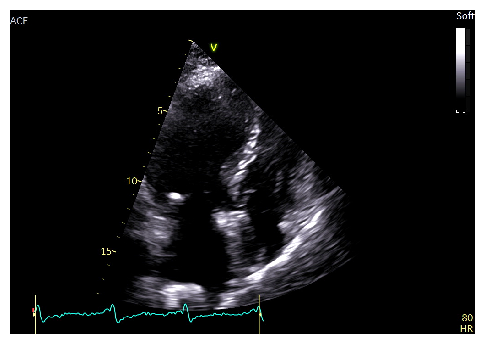

In [48]:
# Simple animation preview in the notebook
# Note: For large cine loops this can be slow; adjust 'step' to skip frames.
import matplotlib.animation as animation

step = 1  # e.g., 2 or 3 to speed up
frames_to_show = list(range(0, T, step)) if T > 1 else [0]

fig = plt.figure(figsize=(6,6))
im = plt.imshow(arr8[frames_to_show[0]], cmap='gray', origin='upper', interpolation='nearest')
plt.axis('off')

def update(k):
    im.set_data(arr8[frames_to_show[k]])
    return [im]

interval_ms = int((frame_time_s or (1.0/(fps or 30))) * 1000) if (frame_time_s or fps) else 33
ani = animation.FuncAnimation(fig, update, frames=len(frames_to_show), interval=interval_ms, blit=True)
plt.show()



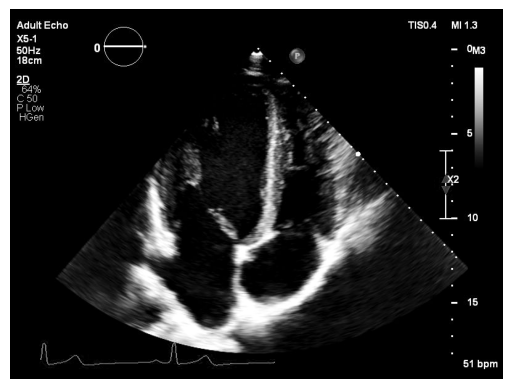

In [25]:
import matplotlib.pyplot as plt
import SimpleITK as sitk

# Load DICOM
img = sitk.ReadImage(dicom_path)
arr = sitk.GetArrayFromImage(img)  # Shape: (T, Y, X) or (Y, X)

# Select one frame (e.g., first frame)
frame_idx = 0
frame = arr[frame_idx] if arr.ndim == 3 else arr

# Show clean image without burned-in text
plt.imshow(frame[100,...,0], cmap="gray")
plt.axis("off")
plt.show()


In [6]:
import SimpleITK as sitk
img = sitk.ReadImage(r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\echo1\1-1.dcm")
sitk.WriteImage(img, r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\echo1\echo1.nrrd")
# or .mha also works well:
# sitk.WriteImage(img, r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\echo1\echo1.mha")


In [10]:
import SimpleITK as sitk
input_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\dcms2\echo1\test_a4c.nrrd"
img = sitk.ReadImage(input_path)

# Check the range of signal intensity
arr_img = sitk.GetArrayFromImage(img)
print(f"Signal intensity range: min={arr_img.min()}, max={arr_img.max()}")

# print(img)

Signal intensity range: min=0, max=255


In [2]:
import SimpleITK as sitk
import os

in_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\echo\echo1\1-1.dcm"
out_path = in_path.replace(".dcm", "_sitk_fixed.dcm")

# Read DICOM
reader = sitk.ImageFileReader()
reader.SetFileName(in_path)
image = reader.Execute()

# Write back → SITK regenerates a clean DICOM header
writer = sitk.ImageFileWriter()
writer.KeepOriginalImageUIDOn()  # optional: keep same UID if possible
writer.SetFileName(out_path)
writer.Execute(image)

print("Sanitized DICOM saved to:", out_path)


Sanitized DICOM saved to: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\echo\echo1\1-1_sitk_fixed.dcm


In [5]:
import SimpleITK as sitk

in_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\echo\echo1\1-1.dcm"

out_path = in_path.replace(".dcm", "_fixed.dcm")

image = sitk.ReadImage(in_path)

writer = sitk.ImageFileWriter()
writer.SetFileName(out_path)
writer.UseCompressionOn()          # enable compression if supported
writer.Execute(image)

print("Saved:", out_path)


Saved: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\precision-medicine-toolbox_dev\data2\echo\echo1\1-1_fixed.dcm
